# **5. Support Vector Machine**

**SVM** is a **supervised learning algorithm** used for:
- Classification  
- Regression  
- Outlier detection  

**📌 Core Idea**
Find the **optimal hyperplane** that separates classes with the **maximum margin**.



**Hyperplane & Margin**

- **Hyperplane** → Decision boundary separating classes  
- **Margin** → Distance between the hyperplane and nearest data points  
- **Support Vectors** → Closest data points that define the hyperplane  

🎯 **SVM aims to maximize the margin**


**Wine Dataset (Scikit-learn)**


The **Wine dataset** is a **multiclass classification** problem.

**Goal:**  Classify wine samples into **3 different wine classes** based on chemical properties.


**About the Wine Dataset**

- **Samples:** 178  
- **Features:** 13 (all numeric)  
- **Classes:** 3 (`class_0`, `class_1`, `class_2`)  

**Example Features**
- Alcohol  
- Malic acid  
- Ash  
- Magnesium  
- Flavanoids  
- Color intensity  
- Proline, etc.

📌 Small, clean dataset → **ideal for demonstrating SVM**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Load the Wine Dataset**

In [ ]:
wine = load_wine()
X = wine.data
y = wine.target

**Dataset Information**

In [ ]:
print("Feature names:", wine.feature_names)
print("Target names:", wine.target_names)
print("Shape of data:", X.shape)

Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target names: ['class_0' 'class_1' 'class_2']
Shape of data: (178, 13)


**Convert to DataFrame (for visualization)**

In [ ]:
df = pd.DataFrame(X, columns=wine.feature_names)
df["target"] = y
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


**Class Distribution Visualization**

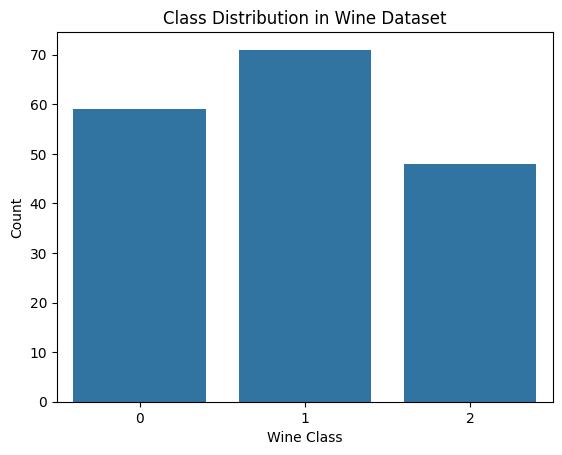

In [ ]:
sns.countplot(x="target", data=df)
plt.title("Class Distribution in Wine Dataset")
plt.xlabel("Wine Class")
plt.ylabel("Count")
plt.show()

**Feature Visualization**

Alcohol vs Color Intensity

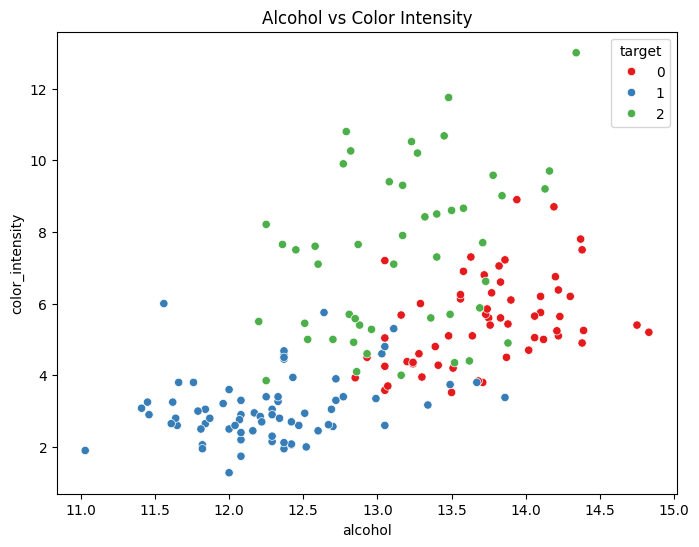

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df["alcohol"],
    y=df["color_intensity"],
    hue=df["target"],
    palette="Set1"
)
plt.title("Alcohol vs Color Intensity")
plt.show()

**Train–Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

**Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Train SVM Classifier**

In [ ]:
svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train_scaled, y_train)

SVC(C=1)

**Prediction & Accuracy**

In [ ]:
y_pred = svm.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9777777777777777


**Confusion Matrix Visualization**

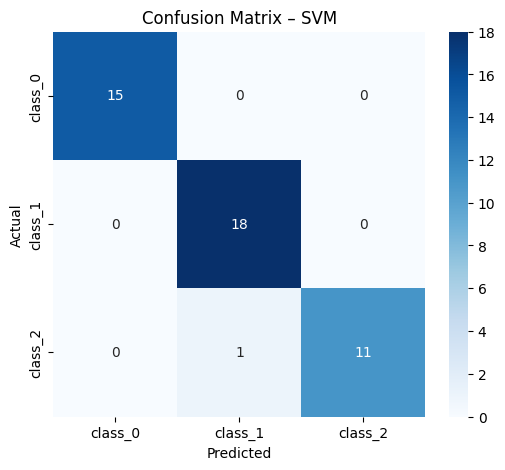

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – SVM")
plt.show()

**Classification Report**

In [ ]:
print(classification_report(y_test, y_pred, target_names=wine.target_names))

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       0.95      1.00      0.97        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.98        45
weighted avg       0.98      0.98      0.98        45



# **6. Naive Bayes**


Naive Bayes is a **probabilistic supervised learning** algorithm based on **Bayes’ Theorem**.

**📌 Key Idea**
Predict the class with the **highest posterior probability** given the input features.

**Bayes’ Theorem**

$$ P(Class | Features) =  
[P(Features | Class) × P(Class)] / P(Features) $$


Where:

- **Prior**  
  P(Class) → Probability of a class (e.g., survival rate)

- **Likelihood**  
  P(Features | Class) → Probability of features given class

- **Posterior**  
  → Final probability used for prediction

- **Evidence**  
  P(Features) → Constant (can be ignored for comparison)



**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Load the Dataset**


- **train_test_split** → Splits data into training and testing sets  
- **GaussianNB** → Naive Bayes classifier for continuous data  
- **accuracy_score** → Calculates prediction accuracy  
- **confusion_matrix** → Shows correct vs incorrect predictions  
- **classification_report** → Gives precision, recall, F1-score  


**Load the Titanic Dataset**

- Click Files (📁) → Upload

- Upload Titanic-Dataset.csv

In [11]:
df = pd.read_csv('/content/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Data Cleaning & Preprocessing**

- Select important features only

- Fill missing Age values with mean

- Convert categorical feature Sex to numeric

In [12]:
df = df[['Pclass', 'Sex', 'Age', 'Fare', 'Survived']].copy()

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'] = df['Age'].fillna(df['Age'].mean())

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [13]:
df.head()

,Pclass,Sex,Age,Fare,Survived
0,3,0,22.0,7.2500,0
1,1,1,38.0,71.2833,1
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,1
4,3,0,35.0,8.0500,0


**Feature-wise Visualization**

Survival by Gender

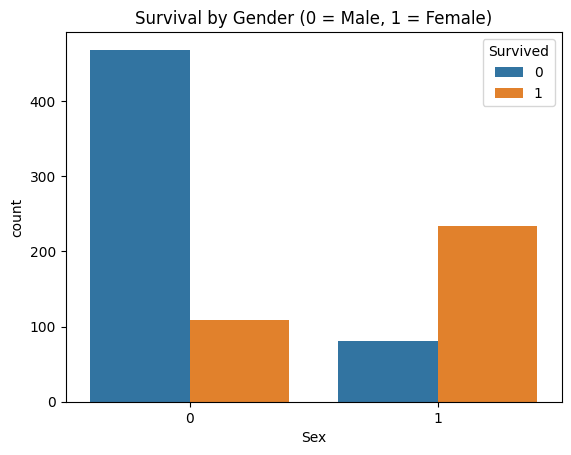

In [15]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender (0 = Male, 1 = Female)")
plt.show()

Survival by Passenger Class

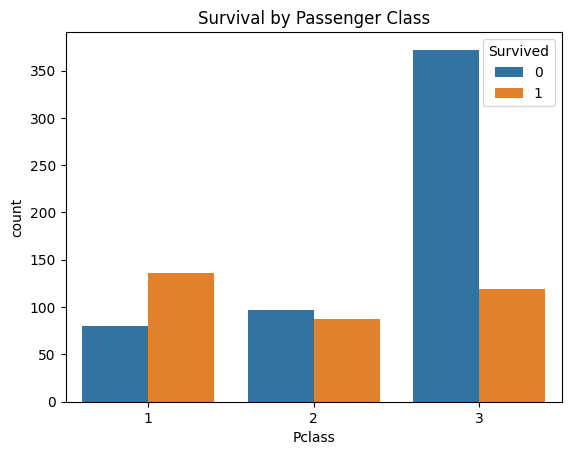

In [16]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

**Split Data into Features and Target**

📌 80% training data, 20% testing data

In [17]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

**Train Naive Bayes Classifier**

Gaussian Naive Bayes

- Used when features are continuous

- Assumes data follows a normal distribution

**Prediction & Accuracy**

In [19]:
y_pred = nb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7597765363128491


**Confusion Matrix**

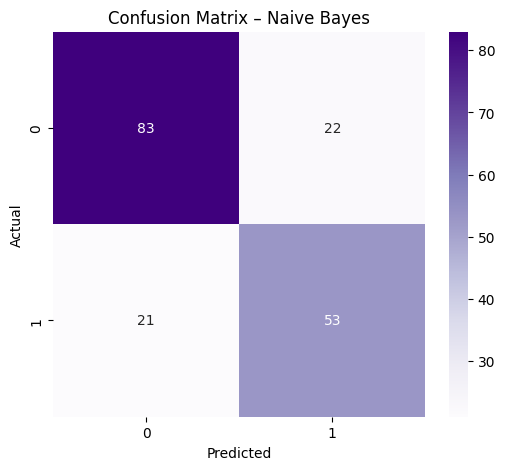

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Naive Bayes")
plt.show()

**Classification Report**

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.79      0.79       105
           1       0.71      0.72      0.71        74

    accuracy                           0.76       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.76      0.76       179

